# TTM vs Traditional Forecasters — Rolling OOS on FEDFUNDS

Rolling 1-step-ahead OOS comparison of IBM TTM (zero-shot foundation model) against the traditional forecasters developed in `timesfm_google/benchmark/`.

In [6]:
import sys, os, logging

GRANITE_DIR = os.path.dirname(os.path.abspath('__file__'))
TIMESFM_DIR = os.path.abspath(os.path.join(GRANITE_DIR, '..', 'timesfm_google'))

for p in [GRANITE_DIR, TIMESFM_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

# suppress the expected "monthly freq not in mapping" warning — it uses
# the root logger directly, so we filter there
class _FreqTokenFilter(logging.Filter):
    def filter(self, record):
        return 'Frequency token' not in record.getMessage()

logging.getLogger().addFilter(_FreqTokenFilter())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

from tsfm_public import (
    TimeSeriesForecastingPipeline,
    TimeSeriesPreprocessor,
    TinyTimeMixerForPrediction,
)

from benchmark import (
    NaiveBenchmarkForecaster,
    ARIMAForecaster,
    AutoARIMAForecaster,
    BayesianARForecaster,
    MLBayesARForecaster,
    SSAForecaster,
)

print('All imports OK')

All imports OK


## Config

In [7]:
CSV_PATH   = 'data/FEDFUNDS.csv'
DATE_COL   = 'observation_date'
TARGET_COL = 'FEDFUNDS'

K_FIRST        = 360   # initial training window (months ~= 30 years)
HORIZON        = 1     # steps ahead
TTM_CONTEXT    = 512   # max context length for TTM
ROLLING_WINDOW = 36    # window for rolling MSE chart

device = (
    'mps'  if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(f'device = {device}')

device = mps


## Load data

n = 861  (1954-07-01 → 2026-03-01)


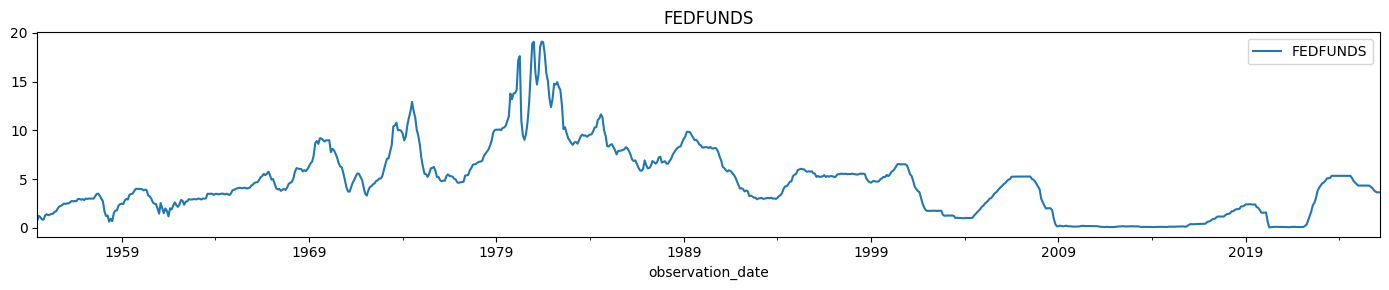

In [8]:
df = (
    pd.read_csv(CSV_PATH, parse_dates=[DATE_COL])
    [[DATE_COL, TARGET_COL]]
    .dropna()
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)

values = df[TARGET_COL].values.astype(float)
dates  = df[DATE_COL].values
n      = len(df)
print(f'n = {n}  ({df[DATE_COL].iloc[0].date()} → {df[DATE_COL].iloc[-1].date()})')
df.plot(x=DATE_COL, y=TARGET_COL, figsize=(14, 3), title='FEDFUNDS')
plt.tight_layout(); plt.show()

## Initialise models

TTM is zero-shot — initialised once.  
Traditional forecasters refit at every origin (that's their normal operating mode).

In [9]:
# ── TTM ──────────────────────────────────────────────────────────────────
_ctx         = min(TTM_CONTEXT, K_FIRST)
_init_ctx_df = df.iloc[K_FIRST - _ctx : K_FIRST].copy()

tsp = TimeSeriesPreprocessor(
    timestamp_column=DATE_COL,
    target_columns=[TARGET_COL],
    context_length=_ctx,
    prediction_length=max(HORIZON, 1),
    scaling=True,
    encode_categorical=False,
    scaler_type='standard',
)
tsp = tsp.train(_init_ctx_df)

ttm_model = TinyTimeMixerForPrediction.from_pretrained(
    'ibm-granite/granite-timeseries-ttm-r2',
    revision='512-96-ft-r2.1',
    num_input_channels=tsp.num_input_channels,
)

ttm_pipeline = TimeSeriesForecastingPipeline(
    ttm_model,
    device=device,
    feature_extractor=tsp,
    batch_size=512,
    add_known_ground_truth=False,
)
print('TTM ready')

# ── Traditional forecasters (refit each origin) ───────────────────────────
traditional = {
    'Naive':       NaiveBenchmarkForecaster(),
    'AR(1)':       ARIMAForecaster(order=(1, 0, 0)),
    'AutoARIMA':   AutoARIMAForecaster(p_max=4, q_max=2, d_max=2),
    'BayesAR':     BayesianARForecaster(p=3, prior_precision=1.0, prior_mode='ridge'),
    'MLBayesAR':   MLBayesARForecaster(p=24, prior_mode='minnesota'),
    'SSA':         SSAForecaster(),
}
print(f'Traditional forecasters: {list(traditional.keys())}')

Device set to use mps


TTM ready
Traditional forecasters: ['Naive', 'AR(1)', 'AutoARIMA', 'BayesAR', 'MLBayesAR', 'SSA']


## Rolling-window OOS loop

In [10]:
origins      = list(range(K_FIRST, n - HORIZON + 1))
actuals      = []
origin_dates = []
ttm_preds    = []
trad_preds   = {name: [] for name in traditional}

for k in tqdm(origins, desc='Rolling OOS'):
    actuals.append(values[k + HORIZON - 1])
    origin_dates.append(dates[k])
    history = values[:k]

    # ── TTM ──────────────────────────────────────────────────────────────
    ctx_len = min(TTM_CONTEXT, k)
    ctx_df  = df.iloc[k - ctx_len : k].copy().reset_index(drop=True)

    # refit scaler on current context window at each origin
    tsp_k = TimeSeriesPreprocessor(
        timestamp_column=DATE_COL,
        target_columns=[TARGET_COL],
        context_length=ctx_len,
        prediction_length=max(HORIZON, 1),
        scaling=True,
        encode_categorical=False,
        scaler_type='standard',
    )
    tsp_k = tsp_k.train(ctx_df)

    pipeline_k = TimeSeriesForecastingPipeline(
        ttm_model,
        device=device,
        feature_extractor=tsp_k,
        batch_size=512,
        add_known_ground_truth=False,
    )

    try:
        fcast    = pipeline_k(ctx_df)
        pred_col = f'{TARGET_COL}_prediction' if f'{TARGET_COL}_prediction' in fcast.columns else TARGET_COL
        pred_arr = np.asarray(fcast.iloc[-1][pred_col], dtype=float)
        ttm_preds.append(pred_arr[HORIZON - 1])
    except Exception:
        ttm_preds.append(np.nan)

    # ── Traditional ───────────────────────────────────────────────────────
    for name, fc in traditional.items():
        try:
            pred_arr = fc.fit_predict(history, HORIZON)
            trad_preds[name].append(float(pred_arr[HORIZON - 1]))
        except Exception:
            trad_preds[name].append(np.nan)

actuals      = np.array(actuals, dtype=float)
ttm_preds    = np.array(ttm_preds, dtype=float)
origin_dates = pd.to_datetime(origin_dates)
trad_preds   = {k: np.array(v, dtype=float) for k, v in trad_preds.items()}

print(f'Done. Origins: {len(origins)}')

Rolling OOS:   0%|          | 0/501 [00:00<?, ?it/s]

Device set to use mps
INFO:p-4855:t-8705831168:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 512, 'frequency_token': 0, 'id_columns': [], 'timestamp_column': 'observation_date', 'target_columns': ['FEDFUNDS'], 'observable_columns': [], 'control_columns': [], 'conditional_columns': [], 'categorical_columns': [], 'static_categorical_columns': []}
Device set to use mps
INFO:p-4855:t-8705831168:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 512, 'frequency_token': 0, 'id_columns': [], 'timestamp_column': 'observation_date', 'target_columns': ['FEDFUNDS'], 'observable_columns': [], 'control_columns': [], 'conditional_columns': [], 'categorical_columns': [], 'static_categorical_columns': []}
Device set to use mps
INFO:p-4855:t-8705831168:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 512, 'frequency_to

Done. Origins: 501


## Summary metrics

In [11]:
def metrics(preds, actuals):
    mask = ~np.isnan(preds)
    e    = preds[mask] - actuals[mask]
    return {'N': int(mask.sum()), 'MSE': np.mean(e**2),
            'RMSE': np.sqrt(np.mean(e**2)), 'MAE': np.mean(np.abs(e))}

rows = [{'Forecaster': 'TTM (granite)', **metrics(ttm_preds, actuals)}]
for name, preds in trad_preds.items():
    rows.append({'Forecaster': name, **metrics(preds, actuals)})

summary = pd.DataFrame(rows)
display(summary.set_index('Forecaster').round(5))

,N,MSE,RMSE,MAE
Forecaster,,,,
TTM (granite),501,0.14390,0.37934,0.28353
Naive,501,0.04554,0.21339,0.12447
AR(1),501,0.04557,0.21348,0.13233
AutoARIMA,501,0.03670,0.19156,0.12385
BayesAR,501,0.03508,0.18730,0.11249
MLBayesAR,501,0.03791,0.19470,0.12109
SSA,501,0.05692,0.23857,0.16384


## Plots

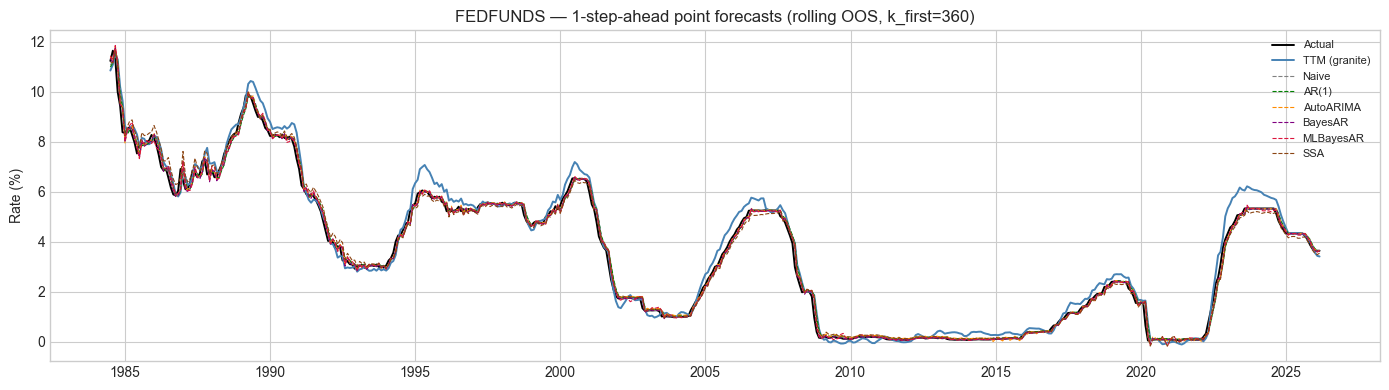

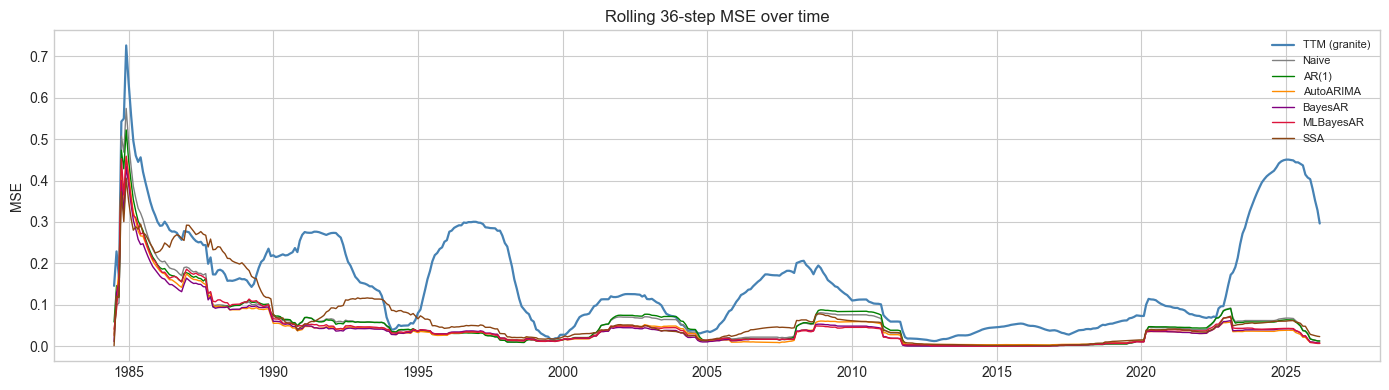

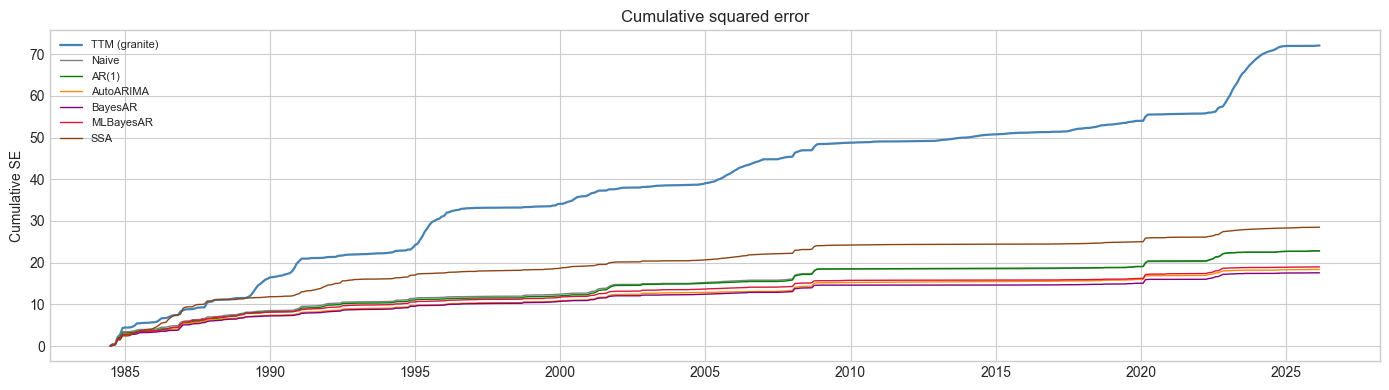

In [12]:
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {
    'TTM (granite)': 'steelblue',
    'Naive':         'gray',
    'AR(1)':         'green',
    'AutoARIMA':     'darkorange',
    'BayesAR':       'purple',
    'MLBayesAR':     'crimson',
    'SSA':           'saddlebrown',
}

all_preds = {'TTM (granite)': ttm_preds, **trad_preds}
sq_errs   = {name: (p - actuals)**2 for name, p in all_preds.items()}

def rolling_mean(x, w):
    return pd.Series(x).rolling(w, min_periods=1).mean().values

# ── 1. Point forecasts vs actuals ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(origin_dates, actuals, label='Actual', color='black', linewidth=1.4)
for name, preds in all_preds.items():
    lw = 1.4 if name == 'TTM (granite)' else 0.8
    ls = '-'  if name == 'TTM (granite)' else '--'
    ax.plot(origin_dates, preds, label=name, color=COLORS[name], linewidth=lw, linestyle=ls)
ax.set_title(f'FEDFUNDS — {HORIZON}-step-ahead point forecasts (rolling OOS, k_first={K_FIRST})')
ax.legend(fontsize=8); ax.set_ylabel('Rate (%)')
plt.tight_layout(); plt.show()

# ── 2. Rolling MSE ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
for name, se in sq_errs.items():
    lw = 1.6 if name == 'TTM (granite)' else 1.0
    ax.plot(origin_dates, rolling_mean(se, ROLLING_WINDOW),
            label=name, color=COLORS[name], linewidth=lw)
ax.set_title(f'Rolling {ROLLING_WINDOW}-step MSE over time')
ax.legend(fontsize=8); ax.set_ylabel('MSE')
plt.tight_layout(); plt.show()

# ── 3. Cumulative squared error ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
for name, se in sq_errs.items():
    lw = 1.6 if name == 'TTM (granite)' else 1.0
    ax.plot(origin_dates, np.nancumsum(se), label=name, color=COLORS[name], linewidth=lw)
ax.set_title('Cumulative squared error')
ax.legend(fontsize=8); ax.set_ylabel('Cumulative SE')
plt.tight_layout(); plt.show()

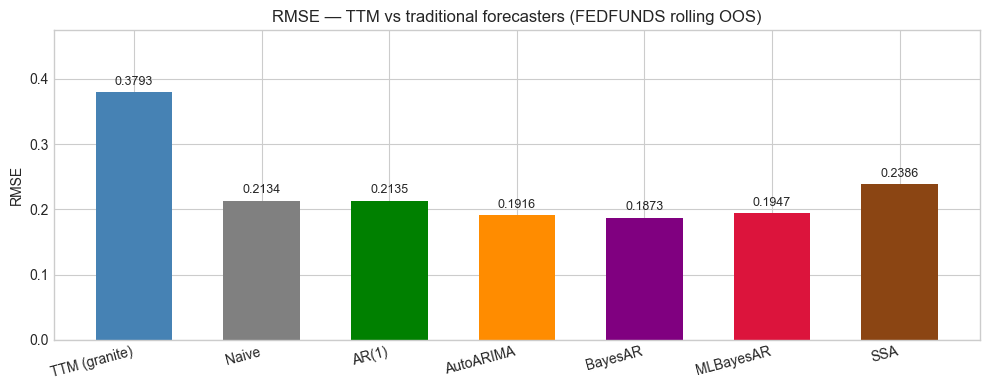

In [13]:
# ── Bar chart: RMSE ───────────────────────────────────────────────────────
names = summary['Forecaster'].tolist()
rmses = summary['RMSE'].tolist()
bar_colors = [COLORS.get(n, 'steelblue') for n in names]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(names, rmses, color=bar_colors, width=0.6)
ax.bar_label(bars, fmt='{:.4f}', padding=3, fontsize=9)
ax.set_title('RMSE — TTM vs traditional forecasters (FEDFUNDS rolling OOS)')
ax.set_ylabel('RMSE')
ax.set_ylim(0, max(rmses) * 1.25)
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()